In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed


--- Checking Dataset Structure and Image Counts ---
Class 'im_Dyskeratotic': Found 1036 images.
Class 'im_Koilocytotic': Found 1063 images.
Class 'im_Metaplastic': Found 1064 images.
Class 'im_Parabasal': Found 895 images.
Class 'im_Superficial-Intermediate': Found 957 images.

Total images found across all classes: 5015


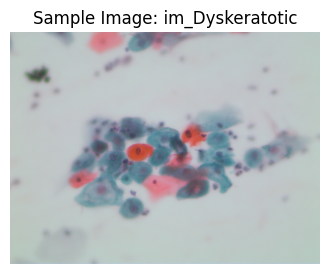

In [5]:
import os
import glob
import matplotlib.pyplot as plt
from PIL import Image

# Define the path to your dataset folders 
# (Update this path if your folders are nested inside another directory)
dataset_path = "/kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed" 

# List the expected SipakMed classes
classes = [
    'im_Dyskeratotic', 
    'im_Koilocytotic', 
    'im_Metaplastic', 
    'im_Parabasal', 
    'im_Superficial-Intermediate'
]

print("--- Checking Dataset Structure and Image Counts ---")
total_images = 0
for cls in classes:
    cls_dir = os.path.join(dataset_path, cls)
    if os.path.exists(cls_dir):
        # Count files in the subdirectories
        image_files = glob.glob(os.path.join(cls_dir, "**", "*.bmp"), recursive=True)
        if len(image_files) == 0:
            image_files = glob.glob(os.path.join(cls_dir, "**", "*.jpg"), recursive=True)
        print(f"Class '{cls}': Found {len(image_files)} images.")
        total_images += len(image_files)
    else:
        print(f"Class '{cls}': Directory not found at {cls_dir}. Please check your path.")

print(f"\nTotal images found across all classes: {total_images}")

# Visualize a sample image from the first available class
for cls in classes:
    cls_dir = os.path.join(dataset_path, cls)
    if os.path.exists(cls_dir):
        sample_files = glob.glob(os.path.join(cls_dir, "**", "*.bmp"), recursive=True)
        if not sample_files:
            sample_files = glob.glob(os.path.join(cls_dir, "**", "*.jpg"), recursive=True)
        
        if sample_files:
            img_path = sample_files[0]
            img = Image.open(img_path)
            plt.figure(figsize=(4, 4))
            plt.imshow(img)
            plt.title(f"Sample Image: {cls}")
            plt.axis('off')
            plt.show()
            break

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

# 1. Define Data Transformations (Resize to 224x224 and normalize)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Load Dataset using ImageFolder (automatically maps folder names to class labels)
full_dataset = datasets.ImageFolder(root=dataset_path, transform=transform)

print(f"Classes found by PyTorch: {full_dataset.classes}")

# 3. Split Dataset into Training (80%) and Validation (20%) sets
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# 4. Create DataLoaders for batching
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

# 5. Initialize a Lightweight Baseline Model (MobileNetV3-Small)
# We modify the final classifier layer to output 5 classes instead of 1000 (ImageNet default)
model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
model.classifier[3] = nn.Linear(model.classifier[3].in_features, len(full_dataset.classes))

# Move model to GPU if available (Colab will use GPU automatically)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"Model successfully loaded and moved to device: {device}")

Classes found by PyTorch: ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic', 'im_Parabasal', 'im_Superficial-Intermediate']
Training batches: 126
Validation batches: 32
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 129MB/s]


Model successfully loaded and moved to device: cuda


In [14]:
# Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Number of epochs for today's quick baseline test (set to 3 or 5 to see results fast)
num_epochs = 3

print("--- Starting Baseline Model Training ---")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    # Training Loop
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Zero the parameter gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimization
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total_train += labels.size(0)
        correct_train += predicted.eq(labels).sum().item()
        
    epoch_train_loss = running_loss / total_train
    epoch_train_acc = 100.0 * correct_train / total_train
    
    # Validation Loop
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()
            
    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = 100.0 * correct_val / total_val
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

print("\n--- Baseline Training Complete! ---")

--- Starting Baseline Model Training ---
Epoch [1/3] | Train Loss: 0.4306 | Train Acc: 84.52% | Val Loss: 0.7592 | Val Acc: 79.06%
Epoch [2/3] | Train Loss: 0.2340 | Train Acc: 91.53% | Val Loss: 0.3735 | Val Acc: 90.03%
Epoch [3/3] | Train Loss: 0.1985 | Train Acc: 93.37% | Val Loss: 0.2056 | Val Acc: 93.62%

--- Baseline Training Complete! ---


In [15]:
import os

print(os.listdir("/kaggle/working"))

['.virtual_documents']


In [16]:
# Save the trained baseline model

import torch
import os

torch.save(model.state_dict(), "/kaggle/working/baseline_model.pth")

print("Model saved successfully!")
print(os.listdir("/kaggle/working"))

Model saved successfully!
['baseline_model.pth', '.virtual_documents']


In [17]:
torch.save({
    'epoch': num_epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'val_accuracy': epoch_val_acc,
    'val_loss': epoch_val_loss
}, "/kaggle/working/baseline_checkpoint.pth")

print("Checkpoint saved!")

Checkpoint saved!


In [18]:
print(os.listdir("/kaggle/working"))

['baseline_checkpoint.pth', 'baseline_model.pth', '.virtual_documents']


In [11]:
import copy
from torch.utils.data import Subset

# 1. Define number of client nodes (simulating decentralized hospitals)
num_clients = 3
print(f"Simulating {num_clients} client nodes for Federated Learning.")

# 2. Partition the training dataset among clients
total_train_len = len(train_dataset)
split_size = total_train_len // num_clients
client_datasets = []

# Shuffle indices to distribute data across clients
indices = torch.randperm(total_train_len).tolist()

for i in range(num_clients):
    start_idx = i * split_size
    end_idx = (i + 1) * split_size if i < num_clients - 1 else total_train_len
    client_indices = indices[start_idx:end_idx]
    client_datasets.append(Subset(train_dataset, client_indices))
    print(f"Client Node {i+1}: Assigned {len(client_indices)} training samples.")

# 3. Create DataLoaders for each client
client_loaders = [DataLoader(ds, batch_size=32, shuffle=True, num_workers=2) for ds in client_datasets]

# 4. Define the Federated Averaging (FedAvg) Simulation Function
def run_federated_learning(global_model, client_loaders, val_loader, num_rounds=5, local_epochs=3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    for round_idx in range(num_rounds):
        print(f"\n--- Federated Training Round [{round_idx+1}/{num_rounds}] ---")
        
        client_weights = []
        global_weights = global_model.state_dict()
        
        # Step A: Local Training on each client node
        for client_id, loader in enumerate(client_loaders):
            # Initialize a local client model copy
            local_model = models.mobilenet_v3_small(weights=None)
            local_model.classifier[3] = nn.Linear(local_model.classifier[3].in_features, len(full_dataset.classes))
            local_model.load_state_dict(global_weights)
            local_model.to(device)
            
            optimizer = optim.Adam(local_model.parameters(), lr=0.001)
            criterion = nn.CrossEntropyLoss()
            
            local_model.train()
            for epoch in range(local_epochs):
                for images, labels in loader:
                    images, labels = images.to(device), labels.to(device)
                    optimizer.zero_grad()
                    outputs = local_model(images)
                    loss = criterion(outputs, labels)
                    loss.backward()
                    optimizer.step()
            
            # Save the trained local weights (privacy preserved: no raw data leaves the client)
            client_weights.append(copy.deepcopy(local_model.state_dict()))
            print(f"Client Node {client_id+1} completed local training.")
            
        # Step B: Global Aggregation (FedAvg)
        new_global_weights = copy.deepcopy(client_weights[0])
        for key in new_global_weights.keys():
            for i in range(1, len(client_weights)):
                new_global_weights[key] += client_weights[i][key]
            new_global_weights[key] = new_global_weights[key] / float(len(client_weights))
            
        # Update the global model with averaged weights
        global_model.load_state_dict(new_global_weights)
        
        # Step C: Evaluate Global Model Performance
        global_model.eval()
        correct_val, total_val = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = global_model(images)
                _, predicted = outputs.max(1)
                total_val += labels.size(0)
                correct_val += predicted.eq(labels).sum().item()
                
        val_acc = 100.0 * correct_val / total_val
        print(f"Global Model Accuracy after Round {round_idx+1}: {val_acc:.2f}%")

    return global_model

# Run the federated simulation using your baseline model
federated_model = run_federated_learning(model, client_loaders, val_loader, num_rounds=5, local_epochs=3)

Simulating 3 client nodes for Federated Learning.
Client Node 1: Assigned 1337 training samples.
Client Node 2: Assigned 1337 training samples.
Client Node 3: Assigned 1338 training samples.

--- Federated Training Round [1/5] ---
Client Node 1 completed local training.
Client Node 2 completed local training.
Client Node 3 completed local training.
Global Model Accuracy after Round 1: 96.81%

--- Federated Training Round [2/5] ---
Client Node 1 completed local training.
Client Node 2 completed local training.
Client Node 3 completed local training.
Global Model Accuracy after Round 2: 96.71%

--- Federated Training Round [3/5] ---
Client Node 1 completed local training.
Client Node 2 completed local training.
Client Node 3 completed local training.
Global Model Accuracy after Round 3: 97.71%

--- Federated Training Round [4/5] ---
Client Node 1 completed local training.
Client Node 2 completed local training.
Client Node 3 completed local training.
Global Model Accuracy after Round 4: 

In [14]:
torch.save(
    federated_model.state_dict(),
    "/kaggle/working/federated_model_round5.pth"
)

In [15]:
torch.save({
    "round": 5,
    "model_state_dict": federated_model.state_dict(),
    "round_accuracies": [96.81, 96.71, 97.71, 96.91, 98.21]
}, "/kaggle/working/federated_checkpoint_round5.pth")

In [16]:
import os

print(os.listdir("/kaggle/working"))

['federated_model_round5.pth', '.virtual_documents', 'federated_checkpoint_round5.pth']


In [18]:
fl_checkpoint = {
    "round": 5,
    "num_rounds": 5,
    "local_epochs": 3,
    "num_clients": 3,
    "model_state_dict": federated_model.state_dict(),

    "round_accuracies": [
        96.81,
        96.71,
        97.71,
        96.91,
        98.21
    ],

    "baseline_accuracy": 93.62,
    "final_accuracy": 98.21
}

torch.save(
    fl_checkpoint,
    "/kaggle/working/federated_checkpoint_round5.pth"
)

print("Federated checkpoint saved!")

Federated checkpoint saved!


In [19]:
checkpoint = torch.load(
    "/kaggle/working/federated_checkpoint_round5.pth",
    map_location=device
)

print("Saved round:", checkpoint["round"])
print("Final accuracy:", checkpoint["final_accuracy"])
print("Round accuracies:", checkpoint["round_accuracies"])

Saved round: 5
Final accuracy: 98.21
Round accuracies: [96.81, 96.71, 97.71, 96.91, 98.21]


baseline_model.pth
        ↓
93.62% centralized model

federated_model_round5.pth
        ↓
98.21% FL model

federated_checkpoint_round5.pth
        ↓
Model + experiment information
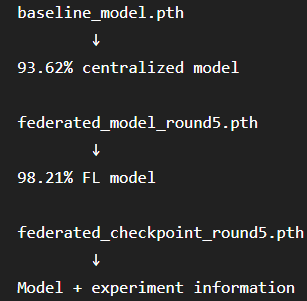

In [21]:
federated_model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = federated_model(images)
        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

final_acc = 100.0 * correct / total

print(f"Final Federated Model Accuracy: {final_acc:.2f}%")

Final Federated Model Accuracy: 98.01%


In [22]:
import pandas as pd

fl_results = pd.DataFrame({
    "round": [1, 2, 3, 4, 5],
    "global_accuracy": [96.81, 96.71, 97.71, 96.91, 98.21]
})

fl_results.to_csv(
    "/kaggle/working/federated_results.csv",
    index=False
)

print(fl_results)

   round  global_accuracy
0      1            96.81
1      2            96.71
2      3            97.71
3      4            96.91
4      5            98.21


In [23]:
import os

print("Files in working directory:")
for file in os.listdir("/kaggle/working"):
    print(" -", file)

Files in working directory:
 - federated_model_round5.pth
 - .virtual_documents
 - federated_results.csv
 - federated_checkpoint_round5.pth


In [28]:
# Install LangChain if not already present in your notebook environment
# !pip install langchain langchain-core

from langchain_core.prompts import PromptTemplate

# 1. Define a medical knowledge mapping for the 5 SipakMed classes
class_medical_profiles = {
    'im_Dyskeratotic': {
        'grade': 'Abnormal / High-Grade Squamous Intraepithelial Precursor',
        'description': 'Shows distinct cellular keratinization and nuclear atypia.',
        'clinical_advice': 'Indicates potential high-grade precancerous changes. Immediate consultation with a gynecological oncologist and a colposcopy-guided biopsy are strongly recommended.'
    },
    'im_Koilocytotic': {
        'grade': 'Abnormal / Low-Grade Precancerous Change (HPV-related)',
        'description': 'Exhibits characteristic koilocytotic halos, indicative of Human Papillomavirus (HPV) infection and mild dysplasia.',
        'clinical_advice': 'Low-grade lesion associated with viral changes. Routine follow-up screening within 6 months and further HPV-typing tests are advised.'
    },
    'im_Metaplastic': {
        'grade': 'Benign / Metaplastic Transformation',
        'description': 'Represents normal tissue healing or cellular adaptation within the transformation zone of the cervix.',
        'clinical_advice': 'Benign finding with favorable prognosis. Standard annual routine cervical screening is recommended.'
    },
    'im_Parabasal': {
        'grade': 'Benign / Immature Squamous Cells',
        'description': 'Normal deep epithelial cells occasionally observed in atrophic or regular physiological smears.',
        'clinical_advice': 'Normal physiological presentation. No immediate clinical intervention required.'
    },
    'im_Superficial-Intermediate': {
        'grade': 'Normal / Healthy Mature Cells',
        'description': 'Normal mature squamous epithelial cells reflecting healthy cellular shedding.',
        'clinical_advice': 'Normal finding. Maintain regular age-appropriate preventive screenings.'
    }
}

# 2. Define a LangChain Prompt Template for structured report generation
report_template = """
You are an expert AI clinical assistant integrated into a privacy-preserving mHealth diagnostic framework. 
Generate a clear, empathetic, and professional diagnostic report based on the following AI classification data:

- Patient ID: {patient_id}
- Predicted Cellular Class: {class_name}
- Diagnostic Classification: {grade}
- Cellular Observations: {description}
- Recommended Clinical Path: {clinical_advice}

Write the report in a structured format containing:
1. Summary of Findings
2. Clinical Interpretation (explained in simple terms suitable for patient understanding)
3. Recommended Next Steps
"""

prompt = PromptTemplate.from_template(report_template)

# 3. Test the Explanation Generator with a sample prediction result
def generate_xai_report(patient_id, predicted_class_name):
    profile = class_medical_profiles.get(predicted_class_name, {
        'grade': 'Unknown', 'description': 'N/A', 'clinical_advice': 'Consult a physician.'
    })
    
    # Format the prompt with dynamic inputs
    formatted_report = prompt.format(
        patient_id=patient_id,
        class_name=predicted_class_name,
        grade=profile['grade'],
        description=profile['description'],
        clinical_advice=profile['clinical_advice']
    )
    return formatted_report

# Example test run for a sample prediction
sample_patient = "P-1042"
sample_prediction = "im_Koilocytotic"

generated_output = generate_xai_report(sample_patient, sample_prediction)
print(generated_output)


You are an expert AI clinical assistant integrated into a privacy-preserving mHealth diagnostic framework. 
Generate a clear, empathetic, and professional diagnostic report based on the following AI classification data:

- Patient ID: P-1042
- Predicted Cellular Class: im_Koilocytotic
- Diagnostic Classification: Abnormal / Low-Grade Precancerous Change (HPV-related)
- Cellular Observations: Exhibits characteristic koilocytotic halos, indicative of Human Papillomavirus (HPV) infection and mild dysplasia.
- Recommended Clinical Path: Low-grade lesion associated with viral changes. Routine follow-up screening within 6 months and further HPV-typing tests are advised.

Write the report in a structured format containing:
1. Summary of Findings
2. Clinical Interpretation (explained in simple terms suitable for patient understanding)
3. Recommended Next Steps

